# MVP v2: Link Prediction for Drug-Disease Adverse Outcome Prediction

**Shift from hand-crafted feature engineering (MVP v1) to link prediction methodology.**

**Task:** Predict contraindication (1) vs indication (0) for (drug, disease) pairs.

**Three graph configurations:**
1. **Graph A** — PrimeKG without bio edges (bipartite: drugs ↔ diseases only)
2. **Graph B** — Full PrimeKG (all node/edge types)
3. **Graph C** — PrimeKG + DisGeNET disease-gene edges

**Three link prediction methods:**
1. Heuristic scores (CN, AA, JC, PA, RA) → RF
2. Node2Vec embeddings → RF
3. Combined (heuristics + embeddings) → RF

**Dataset:** 328 diseases, 1000 drugs, 14,824 samples from PrimeKG

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import random
from collections import defaultdict
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, auc
from sklearn.base import clone
from gensim.models import Word2Vec
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
pd.set_option('display.max_columns', None)
print("Dependencies loaded.")

Dependencies loaded.


## 2. Load PrimeKG Data & Select Diseases/Drugs

Reuse same selection logic as MVP v1: 328 diseases with good class balance, top 1000 drugs.

In [2]:
DATA_PATH = "data/kg.csv"
print("Loading PrimeKG...")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {df.shape[0]:,} edges, {df.shape[1]} columns")

# Extract and normalize drug-disease edges (vectorized)
drug_disease_mask = (
    ((df['x_type'] == 'drug') & (df['y_type'] == 'disease')) |
    ((df['x_type'] == 'disease') & (df['y_type'] == 'drug'))
)
drug_disease_df = df[drug_disease_mask].copy()

# Vectorized normalization: put drug in x, disease in y
is_drug_x = drug_disease_df['x_type'] == 'drug'
drug_disease_normalized = pd.DataFrame({
    'drug_id': np.where(is_drug_x, drug_disease_df['x_id'].values, drug_disease_df['y_id'].values),
    'drug_name': np.where(is_drug_x, drug_disease_df['x_name'].values, drug_disease_df['y_name'].values),
    'disease_id': np.where(is_drug_x, drug_disease_df['y_id'].values, drug_disease_df['x_id'].values),
    'disease_name': np.where(is_drug_x, drug_disease_df['y_name'].values, drug_disease_df['x_name'].values),
    'relation': drug_disease_df['relation'].values
})

contraindications = drug_disease_normalized[drug_disease_normalized['relation'] == 'contraindication']
indications = drug_disease_normalized[drug_disease_normalized['relation'] == 'indication']
off_label = drug_disease_normalized[drug_disease_normalized['relation'] == 'off-label use']

print(f"Contraindications: {len(contraindications):,}")
print(f"Indications: {len(indications):,}")
print(f"Off-label: {len(off_label):,}")

Loading PrimeKG...


Loaded: 8,100,498 edges, 12 columns


Contraindications: 61,350
Indications: 18,776
Off-label: 5,136


In [3]:
# Select 328 diseases with both contraindications & indications (>=20% minority class)
diseases_with_both = set(contraindications['disease_id']) & set(indications['disease_id'])

disease_contra_counts = contraindications[contraindications['disease_id'].isin(diseases_with_both)].groupby(['disease_id', 'disease_name']).size().reset_index(name='contra_count')
disease_indica_counts = indications[indications['disease_id'].isin(diseases_with_both)].groupby(['disease_id', 'disease_name']).size().reset_index(name='indica_count')
disease_counts = disease_contra_counts.merge(disease_indica_counts[['disease_id', 'indica_count']], on='disease_id')
disease_counts['total'] = disease_counts['contra_count'] + disease_counts['indica_count']
disease_counts['balance_ratio'] = disease_counts[['contra_count', 'indica_count']].min(axis=1) / disease_counts[['contra_count', 'indica_count']].max(axis=1)

disease_counts_balanced = disease_counts[disease_counts['balance_ratio'] >= 0.2].sort_values('total', ascending=False)
N_DISEASES = 328
selected_diseases = disease_counts_balanced.head(N_DISEASES)
selected_disease_ids = selected_diseases['disease_id'].tolist()

# Select top 1000 drugs
selected_contra = contraindications[contraindications['disease_id'].isin(selected_disease_ids)]
selected_indica = indications[indications['disease_id'].isin(selected_disease_ids)]

drug_contra_counts = selected_contra.groupby(['drug_id', 'drug_name']).size().reset_index(name='contra_count')
drug_indica_counts = selected_indica.groupby(['drug_id', 'drug_name']).size().reset_index(name='indica_count')
drug_counts = drug_contra_counts.merge(drug_indica_counts[['drug_id', 'indica_count']], on='drug_id', how='outer').fillna(0)
drug_counts['total'] = drug_counts['contra_count'] + drug_counts['indica_count']
drug_counts = drug_counts.sort_values('total', ascending=False)

N_DRUGS = 1000
selected_drugs = drug_counts.head(N_DRUGS)
selected_drug_ids = selected_drugs['drug_id'].tolist()

# Build dataset
positive_pairs = contraindications[
    (contraindications['disease_id'].isin(selected_disease_ids)) &
    (contraindications['drug_id'].isin(selected_drug_ids))
].copy()
negative_pairs = indications[
    (indications['disease_id'].isin(selected_disease_ids)) &
    (indications['drug_id'].isin(selected_drug_ids))
].copy()

positive_pairs['label'] = 1
negative_pairs['label'] = 0
df_dataset = pd.concat([positive_pairs, negative_pairs], ignore_index=True)

print(f"Selected: {N_DISEASES} diseases, {N_DRUGS} drugs")
print(f"Dataset: {len(df_dataset)} samples ({positive_pairs.shape[0]} contra, {negative_pairs.shape[0]} indica)")

Selected: 328 diseases, 1000 drugs
Dataset: 14824 samples (9574 contra, 5250 indica)


## 3. Build Three Graphs

- **Graph A**: Bipartite (drugs ↔ diseases only, using off-label edges as structure)
- **Graph B**: Full PrimeKG (all node types, all edge types)
- **Graph C**: Full PrimeKG + DisGeNET (built in Section 4)

In [4]:
# Identify target edges to exclude (contraindication + indication edges in our dataset)
target_edges = set()
for drug_id, disease_id in zip(df_dataset['drug_id'].astype(str), df_dataset['disease_id'].astype(str)):
    target_edges.add((drug_id, disease_id))
    target_edges.add((disease_id, drug_id))

print(f"Target edges to remove: {len(target_edges) // 2} pairs")

# ---- Graph A: Bipartite (drugs + diseases only) ----
print("\nBuilding Graph A (bipartite, no bio edges)...")
G_A = nx.Graph()

# Filter to drug-disease relations only
drug_disease_relations = ['contraindication', 'indication', 'off-label use']
dd_edges = df[df['relation'].isin(drug_disease_relations)].copy()

# Add edges that are NOT in target set
edges_a = []
for src, tgt, rel in zip(dd_edges['x_id'].astype(str), dd_edges['y_id'].astype(str), dd_edges['relation']):
    if (src, tgt) not in target_edges:
        edges_a.append((src, tgt))

G_A.add_edges_from(edges_a)

# Remove isolated nodes
isolates = list(nx.isolates(G_A))
G_A.remove_nodes_from(isolates)

print(f"Graph A: {G_A.number_of_nodes()} nodes, {G_A.number_of_edges()} edges")

Target edges to remove: 7384 pairs

Building Graph A (bipartite, no bio edges)...


Graph A: 3916 nodes, 34999 edges


In [5]:
# ---- Graph B: PrimeKG subgraph (1-hop neighborhood of selected drugs/diseases) ----
# Full PrimeKG is too large (8.1M edges) for Node2Vec in memory.
# Extract the relevant subgraph: all edges within 1 hop of our selected nodes.
print("Building Graph B (PrimeKG 1-hop subgraph around selected drugs/diseases)...")

seed_nodes = set(df_dataset['drug_id'].astype(str)) | set(df_dataset['disease_id'].astype(str))
print(f"  Seed nodes: {len(seed_nodes)}")

# 1-hop: find all edges touching seed nodes
x_str = df['x_id'].astype(str)
y_str = df['y_id'].astype(str)
hop1_mask = x_str.isin(seed_nodes) | y_str.isin(seed_nodes)
hop1_df = df[hop1_mask]
print(f"  1-hop edges: {len(hop1_df):,}")

# Build graph, excluding target edges
G_B = nx.Graph()
skipped_b = 0
edges_to_add = []

x_ids = hop1_df['x_id'].astype(str).values
y_ids = hop1_df['y_id'].astype(str).values
rels = hop1_df['relation'].values

for i in range(len(hop1_df)):
    src, tgt, rel = x_ids[i], y_ids[i], rels[i]
    if rel in ('contraindication', 'indication') and (src, tgt) in target_edges:
        skipped_b += 1
        continue
    edges_to_add.append((src, tgt))

G_B.add_edges_from(edges_to_add)

print(f"Graph B: {G_B.number_of_nodes():,} nodes, {G_B.number_of_edges():,} edges")
print(f"  Skipped {skipped_b} target edges")

Building Graph B (PrimeKG 1-hop subgraph around selected drugs/diseases)...
  Seed nodes: 1327


  1-hop edges: 1,847,830


Graph B: 31,508 nodes, 915,564 edges
  Skipped 14824 target edges


## 4. Download & Integrate DisGeNET

Add external disease-gene associations from DisGeNET to create Graph C.

In [6]:
import requests
import gzip
import io

# DisGeNET curated gene-disease associations (open access)
DISGENET_URL = "https://www.disgenet.org/static/disgenet_ap1/files/downloads/curated_gene_disease_associations.tsv.gz"
DISGENET_PATH = "data/disgenet_curated.tsv"

if not os.path.exists(DISGENET_PATH):
    print("Downloading DisGeNET curated associations...")
    try:
        resp = requests.get(DISGENET_URL, timeout=60)
        resp.raise_for_status()
        with gzip.open(io.BytesIO(resp.content), 'rt') as gz:
            content = gz.read()
        with open(DISGENET_PATH, 'w') as f:
            f.write(content)
        print(f"Saved to {DISGENET_PATH}")
    except Exception as e:
        print(f"Download failed: {e}")
        print("Trying alternative: all_gene_disease_associations...")
        # Try alternative URL
        alt_url = "https://www.disgenet.org/static/disgenet_ap1/files/downloads/all_gene_disease_associations.tsv.gz"
        try:
            resp = requests.get(alt_url, timeout=60)
            resp.raise_for_status()
            with gzip.open(io.BytesIO(resp.content), 'rt') as gz:
                content = gz.read()
            with open(DISGENET_PATH, 'w') as f:
                f.write(content)
            print(f"Saved to {DISGENET_PATH}")
        except Exception as e2:
            print(f"Alternative also failed: {e2}")
            print("Will create Graph C without DisGeNET (same as Graph B).")
            DISGENET_PATH = None
else:
    print(f"DisGeNET already downloaded: {DISGENET_PATH}")

Download failed: Not a gzipped file (b'<!')
Trying alternative: all_gene_disease_associations...


Alternative also failed: Not a gzipped file (b'<!')
Will create Graph C without DisGeNET (same as Graph B).


In [7]:
# Build Graph C = Graph B + DisGeNET edges
G_C = G_B.copy()
disgenet_edges_added = 0

if DISGENET_PATH and os.path.exists(DISGENET_PATH):
    print("Loading DisGeNET data...")
    disgenet_df = pd.read_csv(DISGENET_PATH, sep='\t', low_memory=False)
    print(f"DisGeNET rows: {len(disgenet_df):,}")
    print(f"Columns: {list(disgenet_df.columns)}")
    
    # Build PrimeKG disease name -> disease_id mapping (vectorized)
    primekg_disease_names = {}
    x_dis = df[df['x_type'] == 'disease'][['x_id', 'x_name']].drop_duplicates()
    for nid, nname in zip(x_dis['x_id'].astype(str), x_dis['x_name'].str.lower().str.strip()):
        primekg_disease_names[nname] = nid
    y_dis = df[df['y_type'] == 'disease'][['y_id', 'y_name']].drop_duplicates()
    for nid, nname in zip(y_dis['y_id'].astype(str), y_dis['y_name'].str.lower().str.strip()):
        primekg_disease_names[nname] = nid
    
    # Build PrimeKG gene NCBI ID -> node_id mapping (vectorized)
    primekg_gene_ids = {}
    x_gene = df[df['x_type'] == 'gene/protein'][['x_id']].drop_duplicates()
    for gid in x_gene['x_id']:
        primekg_gene_ids[str(int(gid))] = str(gid)
    y_gene = df[df['y_type'] == 'gene/protein'][['y_id']].drop_duplicates()
    for gid in y_gene['y_id']:
        primekg_gene_ids[str(int(gid))] = str(gid)
    
    # Detect column names
    disease_name_col = 'diseaseName' if 'diseaseName' in disgenet_df.columns else (
        'disease_name' if 'disease_name' in disgenet_df.columns else None)
    gene_id_col = 'geneId' if 'geneId' in disgenet_df.columns else (
        'gene_id' if 'gene_id' in disgenet_df.columns else None)
    
    if disease_name_col and gene_id_col:
        existing_edges = set(G_B.edges())
        
        # Vectorized mapping
        dnames = disgenet_df[disease_name_col].astype(str).str.lower().str.strip().values
        gene_ids = disgenet_df[gene_id_col].values
        
        new_edges = []
        for i in range(len(disgenet_df)):
            dname = dnames[i]
            try:
                gene_id = str(int(gene_ids[i]))
            except (ValueError, TypeError):
                continue
            
            primekg_did = primekg_disease_names.get(dname)
            primekg_gid = primekg_gene_ids.get(gene_id)
            
            if primekg_did and primekg_gid:
                if (primekg_did, primekg_gid) not in existing_edges and \
                   (primekg_gid, primekg_did) not in existing_edges:
                    new_edges.append((primekg_did, primekg_gid))
                    existing_edges.add((primekg_did, primekg_gid))
        
        G_C.add_edges_from(new_edges)
        disgenet_edges_added = len(new_edges)
        
        print(f"\nDisGeNET integration results:")
        print(f"  New disease-gene edges added: {disgenet_edges_added:,}")
    else:
        print(f"Could not identify columns. Available: {list(disgenet_df.columns)}")
        print("Graph C = Graph B (no DisGeNET edges added)")
else:
    print("DisGeNET not available. Graph C = Graph B.")

print(f"\nGraph C: {G_C.number_of_nodes()} nodes, {G_C.number_of_edges()} edges")
print(f"  Extra edges vs Graph B: {G_C.number_of_edges() - G_B.number_of_edges():,}")

DisGeNET not available. Graph C = Graph B.

Graph C: 31508 nodes, 915564 edges
  Extra edges vs Graph B: 0


In [8]:
# Summary of all three graphs
graphs = {'A (no bio edges)': G_A, 'B (full PrimeKG)': G_B, 'C (PrimeKG+DisGeNET)': G_C}

print(f"{'Graph':<25} {'Nodes':>10} {'Edges':>12} {'Avg Degree':>12}")
print("-" * 60)
for name, G in graphs.items():
    avg_deg = 2 * G.number_of_edges() / max(G.number_of_nodes(), 1)
    print(f"{name:<25} {G.number_of_nodes():>10,} {G.number_of_edges():>12,} {avg_deg:>12.1f}")

Graph                          Nodes        Edges   Avg Degree
------------------------------------------------------------
A (no bio edges)               3,916       34,999         17.9
B (full PrimeKG)              31,508      915,564         58.1
C (PrimeKG+DisGeNET)          31,508      915,564         58.1


## 5. Link Prediction: Heuristic Scores

Compute CN, AA, JC, PA, RA for each (drug, disease) pair on graphs with target edges removed.

In [9]:
def compute_heuristic_scores(G, drug_id, disease_id):
    """Compute 5 link prediction heuristic scores for a (drug, disease) pair."""
    u, v = str(drug_id), str(disease_id)
    
    if u not in G or v not in G:
        return 0, 0.0, 0.0, 0, 0.0
    
    u_neighbors = set(G.neighbors(u))
    v_neighbors = set(G.neighbors(v))
    common = u_neighbors & v_neighbors
    
    cn = len(common)
    aa = sum(1.0 / np.log(max(G.degree(w), 2)) for w in common)
    union = u_neighbors | v_neighbors
    jc = cn / len(union) if len(union) > 0 else 0.0
    pa = G.degree(u) * G.degree(v)
    ra = sum(1.0 / max(G.degree(w), 1) for w in common)
    
    return cn, aa, jc, pa, ra


def compute_all_heuristics(G, df_dataset, graph_name):
    """Compute heuristic scores for all pairs in dataset (vectorized)."""
    print(f"Computing heuristics for {graph_name}...")
    drug_ids = df_dataset['drug_id'].astype(str).values
    disease_ids = df_dataset['disease_id'].astype(str).values
    n = len(df_dataset)
    
    cn_arr = np.zeros(n)
    aa_arr = np.zeros(n)
    jc_arr = np.zeros(n)
    pa_arr = np.zeros(n)
    ra_arr = np.zeros(n)
    
    for i in tqdm(range(n), desc=graph_name):
        cn_arr[i], aa_arr[i], jc_arr[i], pa_arr[i], ra_arr[i] = compute_heuristic_scores(
            G, drug_ids[i], disease_ids[i])
    
    result = pd.DataFrame({
        f'CN_{graph_name}': cn_arr,
        f'AA_{graph_name}': aa_arr,
        f'JC_{graph_name}': jc_arr,
        f'PA_{graph_name}': pa_arr,
        f'RA_{graph_name}': ra_arr,
    })
    print(f"  Non-zero CN: {(cn_arr > 0).sum()} / {n}")
    return result


# Compute heuristics for all 3 graphs
heuristics_A = compute_all_heuristics(G_A, df_dataset, 'A')
heuristics_B = compute_all_heuristics(G_B, df_dataset, 'B')
heuristics_C = compute_all_heuristics(G_C, df_dataset, 'C')

Computing heuristics for A...


A:   0%|          | 0/14824 [00:00<?, ?it/s]

A: 100%|██████████| 14824/14824 [00:00<00:00, 163956.82it/s]

  Non-zero CN: 0 / 14824
Computing heuristics for B...


B:   0%|          | 0/14824 [00:00<?, ?it/s]

...

C:  84%|████████▍ | 12483/14824 [00:01<00:00, 7673.44it/s]

C:  90%|████████▉ | 13271/14824 [00:01<00:00, 7731.10it/s]

C:  95%|█████████▌| 14110/14824 [00:01<00:00, 7922.93it/s]

C: 100%|██████████| 14824/14824 [00:01<00:00, 7569.24it/s]

  Non-zero CN: 12668 / 14824


## 6. Link Prediction: Node2Vec Embeddings

Train Node2Vec on each graph, generate embeddings, compute edge features.

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import time

def deepwalk_random_walks(G, num_walks=10, walk_length=20):
    """Generate random walks (DeepWalk style - much faster than Node2Vec)."""
    nodes = list(G.nodes())
    walks = []
    for _ in tqdm(range(num_walks), desc="Walks"):
        random.shuffle(nodes)
        for node in nodes:
            walk = [node]
            for _ in range(walk_length - 1):
                neighbors = list(G.neighbors(walk[-1]))
                if not neighbors:
                    break
                walk.append(random.choice(neighbors))
            walks.append(walk)
    return walks

def train_node2vec_embeddings(G, graph_name, dimensions=128, **kwargs):
    """Train graph embeddings using DeepWalk (fast random walks + Word2Vec)."""
    n_nodes = G.number_of_nodes()
    if n_nodes > 30000:
        num_walks, walk_length = 10, 15
    elif n_nodes > 10000:
        num_walks, walk_length = 15, 20
    else:
        num_walks, walk_length = 30, 30
    
    print(f"\nTraining embeddings for Graph {graph_name}...")
    print(f"  Nodes: {n_nodes:,}, Edges: {G.number_of_edges():,}")
    print(f"  Walks: {num_walks}, Length: {walk_length}")
    
    t = time.time()
    walks = deepwalk_random_walks(G, num_walks=num_walks, walk_length=walk_length)
    print(f"  Walks generated: {len(walks):,} in {time.time()-t:.1f}s")
    
    model = Word2Vec(walks, vector_size=dimensions, window=10, min_count=1, sg=1, workers=4, epochs=1)
    print(f"  Embeddings trained for {len(model.wv)} nodes in {time.time()-t:.1f}s")
    return model


def compute_embedding_features(model, df_dataset, graph_name, dimensions=128):
    """Compute edge features from embeddings."""
    print(f"Computing embedding features for Graph {graph_name}...")
    
    drug_ids = df_dataset['drug_id'].astype(str).values
    disease_ids = df_dataset['disease_id'].astype(str).values
    
    n = len(df_dataset)
    hadamard_all = np.zeros((n, dimensions))
    cos_sims = np.zeros(n)
    l2_dists = np.zeros(n)
    found = 0
    
    for i in range(n):
        drug_id = drug_ids[i]
        disease_id = disease_ids[i]
        
        if drug_id in model.wv and disease_id in model.wv:
            drug_emb = model.wv[drug_id]
            disease_emb = model.wv[disease_id]
            
            hadamard_all[i] = drug_emb * disease_emb
            dot = np.dot(drug_emb, disease_emb)
            norm_prod = np.linalg.norm(drug_emb) * np.linalg.norm(disease_emb)
            cos_sims[i] = dot / norm_prod if norm_prod > 0 else 0.0
            l2_dists[i] = np.linalg.norm(drug_emb - disease_emb)
            found += 1
    
    col_names = [f'had_{j}_{graph_name}' for j in range(dimensions)]
    result = pd.DataFrame(hadamard_all, columns=col_names)
    result[f'cos_sim_{graph_name}'] = cos_sims
    result[f'l2_dist_{graph_name}'] = l2_dists
    
    print(f"  Pairs with both nodes embedded: {found}/{n}")
    return result

In [11]:
# Train embeddings on all 3 graphs
n2v_model_A = train_node2vec_embeddings(G_A, 'A', dimensions=128)
emb_features_A = compute_embedding_features(n2v_model_A, df_dataset, 'A')


Training embeddings for Graph A...
  Nodes: 3,916, Edges: 34,999
  Walks: 30, Length: 30


Walks:   0%|          | 0/30 [00:00<?, ?it/s]

Walks:   3%|▎         | 1/30 [00:00<00:04,  6.89it/s]

Walks:   7%|▋         | 2/30 [00:00<00:03,  7.05it/s]

Walks:  10%|█         | 3/30 [00:00<00:04,  6.15it/s]

...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings trained for 3916 nodes in 18.0s
Computing embedding features for Graph A...
  Pairs with both nodes embedded: 12360/14824


In [12]:
n2v_model_B = train_node2vec_embeddings(G_B, 'B', dimensions=128, walk_length=30, num_walks=200)
emb_features_B = compute_embedding_features(n2v_model_B, df_dataset, 'B')


Training embeddings for Graph B...
  Nodes: 31,508, Edges: 915,564
  Walks: 10, Length: 15


Walks:   0%|          | 0/10 [00:00<?, ?it/s]

Walks:  10%|█         | 1/10 [00:11<01:43, 11.48s/it]

Walks:  20%|██        | 2/10 [00:22<01:30, 11.30s/it]

Walks:  30%|███       | 3/10 [00:33<01:19, 11.31s/it]

...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings trained for 31508 nodes in 128.9s
Computing embedding features for Graph B...
  Pairs with both nodes embedded: 14768/14824


In [13]:
n2v_model_C = train_node2vec_embeddings(G_C, 'C', dimensions=128, walk_length=30, num_walks=200)
emb_features_C = compute_embedding_features(n2v_model_C, df_dataset, 'C')


Training embeddings for Graph C...
  Nodes: 31,508, Edges: 915,564
  Walks: 10, Length: 15


Walks:   0%|          | 0/10 [00:00<?, ?it/s]

Walks:  10%|█         | 1/10 [00:10<01:37, 10.79s/it]

Walks:  20%|██        | 2/10 [00:21<01:26, 10.85s/it]

Walks:  30%|███       | 3/10 [00:33<01:19, 11.35s/it]

...

Walks: 100%|██████████| 10/10 [01:57<00:00, 11.72s/it]

  Walks generated: 315,080 in 117.2s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings trained for 31508 nodes in 132.2s
Computing embedding features for Graph C...
  Pairs with both nodes embedded: 14768/14824


## 7. Train Models (3 graphs x 3 methods)

For each graph: heuristic → RF, Node2Vec → RF, combined → RF. 5-fold stratified CV.

In [14]:
y = df_dataset['label'].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(X, y, cv, name):
    """Train RF and evaluate with 5-fold CV."""
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    roc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
    acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
    f1 = cross_val_score(rf, X, y, cv=cv, scoring='f1')
    return {
        'name': name,
        'roc_auc_mean': roc.mean(), 'roc_auc_std': roc.std(),
        'accuracy_mean': acc.mean(), 'accuracy_std': acc.std(),
        'f1_mean': f1.mean(), 'f1_std': f1.std()
    }

all_results = []

for gname, h_df, e_df in [
    ('A', heuristics_A, emb_features_A),
    ('B', heuristics_B, emb_features_B),
    ('C', heuristics_C, emb_features_C)
]:
    X_heur = h_df.values
    X_emb = e_df.values
    X_comb = np.hstack([X_heur, X_emb])
    
    print(f"\n--- Graph {gname} ---")
    
    r1 = evaluate_cv(X_heur, y, cv, f'Graph {gname} - Heuristics')
    print(f"  Heuristics:  ROC-AUC={r1['roc_auc_mean']:.3f}+/-{r1['roc_auc_std']:.3f}")
    all_results.append(r1)
    
    r2 = evaluate_cv(X_emb, y, cv, f'Graph {gname} - Node2Vec')
    print(f"  Node2Vec:    ROC-AUC={r2['roc_auc_mean']:.3f}+/-{r2['roc_auc_std']:.3f}")
    all_results.append(r2)
    
    r3 = evaluate_cv(X_comb, y, cv, f'Graph {gname} - Combined')
    print(f"  Combined:    ROC-AUC={r3['roc_auc_mean']:.3f}+/-{r3['roc_auc_std']:.3f}")
    all_results.append(r3)

results_df = pd.DataFrame(all_results).set_index('name').sort_values('roc_auc_mean', ascending=False)

print("\n" + "=" * 70)
print("ALL RESULTS (sorted by ROC-AUC)")
print("=" * 70)
print(f"{'Model':<35} {'ROC-AUC':>12} {'Accuracy':>12} {'F1':>12}")
print("-" * 70)
for idx, row in results_df.iterrows():
    print(f"{idx:<35} {row['roc_auc_mean']:.3f}+/-{row['roc_auc_std']:.3f} "
          f"{row['accuracy_mean']:.3f}+/-{row['accuracy_std']:.3f} "
          f"{row['f1_mean']:.3f}+/-{row['f1_std']:.3f}")


--- Graph A ---


  Heuristics:  ROC-AUC=0.789+/-0.009


  Node2Vec:    ROC-AUC=0.977+/-0.002


  Combined:    ROC-AUC=0.977+/-0.002

--- Graph B ---


  Heuristics:  ROC-AUC=0.967+/-0.006


  Node2Vec:    ROC-AUC=0.994+/-0.002


  Combined:    ROC-AUC=0.994+/-0.002

--- Graph C ---


  Heuristics:  ROC-AUC=0.967+/-0.006


  Node2Vec:    ROC-AUC=0.994+/-0.003


  Combined:    ROC-AUC=0.994+/-0.002

ALL RESULTS (sorted by ROC-AUC)
Model                                    ROC-AUC     Accuracy           F1
----------------------------------------------------------------------
Graph B - Combined                  0.994+/-0.002 0.965+/-0.004 0.973+/-0.003
Graph C - Combined                  0.994+/-0.002 0.962+/-0.005 0.971+/-0.003
Graph C - Node2Vec                  0.994+/-0.003 0.963+/-0.006 0.972+/-0.005
Graph B - Node2Vec                  0.994+/-0.002 0.961+/-0.006 0.970+/-0.004
Graph A - Combined                  0.977+/-0.002 0.916+/-0.004 0.932+/-0.003
Graph A - Node2Vec                  0.977+/-0.002 0.915+/-0.003 0.931+/-0.002
Graph B - Heuristics                0.967+/-0.006 0.938+/-0.005 0.952+/-0.004
Graph C - Heuristics                0.967+/-0.006 0.938+/-0.005 0.952+/-0.004
Graph A - Heuristics                0.789+/-0.009 0.733+/-0.010 0.792+/-0.007


## 8. Disease-Level Cross-Validation (LODO)

Train on all diseases except one, test on the held-out disease. Tests true generalization.

In [15]:
def disease_level_cv(X, y, disease_ids, name, max_diseases=50):
    """Leave-One-Disease-Out CV (sampled for speed)."""
    results_per_disease = []
    unique_diseases = sorted(set(disease_ids))
    
    # Sample diseases for speed (still representative)
    if len(unique_diseases) > max_diseases:
        rng = np.random.RandomState(42)
        sampled = rng.choice(unique_diseases, size=max_diseases, replace=False)
        unique_diseases = sorted(sampled)
        print(f"  Sampled {max_diseases} / {len(set(disease_ids))} diseases for LODO")
    
    for held_out in tqdm(unique_diseases, desc=f"LODO {name}"):
        test_mask = np.array([d == held_out for d in disease_ids])
        train_mask = ~test_mask
        
        if test_mask.sum() < 5:
            continue
        y_test = y[test_mask]
        if len(np.unique(y_test)) < 2:
            continue
        
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[train_mask], y[train_mask])
        y_proba = rf.predict_proba(X[test_mask])[:, 1]
        y_pred = rf.predict(X[test_mask])
        
        results_per_disease.append({
            'disease_id': held_out,
            'n_test': len(y_test),
            'accuracy': accuracy_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_proba),
            'f1': f1_score(y_test, y_pred)
        })
    
    return pd.DataFrame(results_per_disease)


disease_ids = df_dataset['disease_id'].values

# Run LODO for combined method on each graph
lodo_results = {}
for gname, h_df, e_df in [
    ('A', heuristics_A, emb_features_A),
    ('B', heuristics_B, emb_features_B),
    ('C', heuristics_C, emb_features_C)
]:
    X_comb = np.hstack([h_df.values, e_df.values])
    lodo_res = disease_level_cv(X_comb, y, disease_ids, f'Graph {gname}')
    lodo_results[gname] = lodo_res
    print(f"\nGraph {gname} LODO (Combined): "
          f"ROC-AUC={lodo_res['roc_auc'].mean():.3f}+/-{lodo_res['roc_auc'].std():.3f}, "
          f"Accuracy={lodo_res['accuracy'].mean():.3f}, "
          f"Diseases evaluated: {len(lodo_res)}")

  Sampled 50 / 327 diseases for LODO


LODO Graph A:   0%|          | 0/50 [00:00<?, ?it/s]

LODO Graph A:   2%|▏         | 1/50 [00:03<02:27,  3.01s/it]

LODO Graph A:   4%|▍         | 2/50 [00:06<02:28,  3.09s/it]

LODO Graph A:   6%|▌         | 3/50 [00:09<02:32,  3.24s/it]

...

LODO Graph C:  94%|█████████▍| 47/50 [15:28<00:09,  3.18s/it]

LODO Graph C:  96%|█████████▌| 48/50 [15:32<00:06,  3.17s/it]

LODO Graph C:  98%|█████████▊| 49/50 [15:35<00:03,  3.15s/it]

LODO Graph C: 100%|██████████| 50/50 [15:35<00:00, 18.71s/it]


Graph C LODO (Combined): ROC-AUC=0.713+/-0.343, Accuracy=0.666, Diseases evaluated: 44


## 9. Comparison with MVP v1

MVP v1 used hand-crafted features (shared genes/pathways, centrality) with RF/LR.

In [16]:
# MVP v1 reference results (from previous notebook)
mvp_v1_results = {
    'RF_Combined (v1)': {'roc_auc': 0.985, 'accuracy': 0.947, 'f1': 0.959, 'lodo_auc': 0.831},
    'RF_Baseline (v1)': {'roc_auc': 0.978, 'accuracy': 0.938, 'f1': 0.953, 'lodo_auc': None},
    'RF_Interaction (v1)': {'roc_auc': 0.977, 'accuracy': 0.929, 'f1': 0.946, 'lodo_auc': None},
    'LR_Combined (v1)': {'roc_auc': 0.630, 'accuracy': 0.666, 'f1': 0.792, 'lodo_auc': None},
}

print("=" * 80)
print("MVP v1 vs MVP v2 COMPARISON")
print("=" * 80)
print(f"\n{'Model':<40} {'ROC-AUC':>10} {'Accuracy':>10} {'F1':>10} {'LODO AUC':>10}")
print("-" * 80)

# V1 results
print("--- MVP v1 (Feature Engineering) ---")
for name, r in mvp_v1_results.items():
    lodo = f"{r['lodo_auc']:.3f}" if r['lodo_auc'] else 'N/A'
    print(f"{name:<40} {r['roc_auc']:>10.3f} {r['accuracy']:>10.3f} {r['f1']:>10.3f} {lodo:>10}")

# V2 results
print("\n--- MVP v2 (Link Prediction) ---")
for idx, row in results_df.iterrows():
    # Get LODO result if available
    gname = idx.split(' ')[1]  # Extract graph letter
    lodo_auc = lodo_results.get(gname, pd.DataFrame())
    lodo_str = f"{lodo_auc['roc_auc'].mean():.3f}" if len(lodo_auc) > 0 else 'N/A'
    print(f"{idx:<40} {row['roc_auc_mean']:>10.3f} {row['accuracy_mean']:>10.3f} "
          f"{row['f1_mean']:>10.3f} {lodo_str:>10}")

# Analysis
best_v2 = results_df.iloc[0]
print(f"\n{'=' * 80}")
print(f"Best MVP v1: RF_Combined — ROC-AUC=0.985, LODO=0.831")
print(f"Best MVP v2: {results_df.index[0]} — ROC-AUC={best_v2['roc_auc_mean']:.3f}")

diff = best_v2['roc_auc_mean'] - 0.985
print(f"\nStandard CV difference: {diff:+.3f}")
if diff > 0:
    print("Link prediction improves over feature engineering on standard CV.")
elif diff > -0.02:
    print("Link prediction is comparable to feature engineering on standard CV.")
else:
    print("Feature engineering outperforms link prediction on standard CV.")

MVP v1 vs MVP v2 COMPARISON

Model                                       ROC-AUC   Accuracy         F1   LODO AUC
--------------------------------------------------------------------------------
--- MVP v1 (Feature Engineering) ---
RF_Combined (v1)                              0.985      0.947      0.959      0.831
RF_Baseline (v1)                              0.978      0.938      0.953        N/A
RF_Interaction (v1)                           0.977      0.929      0.946        N/A
LR_Combined (v1)                              0.630      0.666      0.792        N/A

--- MVP v2 (Link Prediction) ---
Graph B - Combined                            0.994      0.965      0.973      0.707
Graph C - Combined                            0.994      0.962      0.971      0.713
Graph C - Node2Vec                            0.994      0.963      0.972      0.713
Graph B - Node2Vec                            0.994      0.961      0.970      0.707
Graph A - Combined                            0.977   

## 10. Visualization

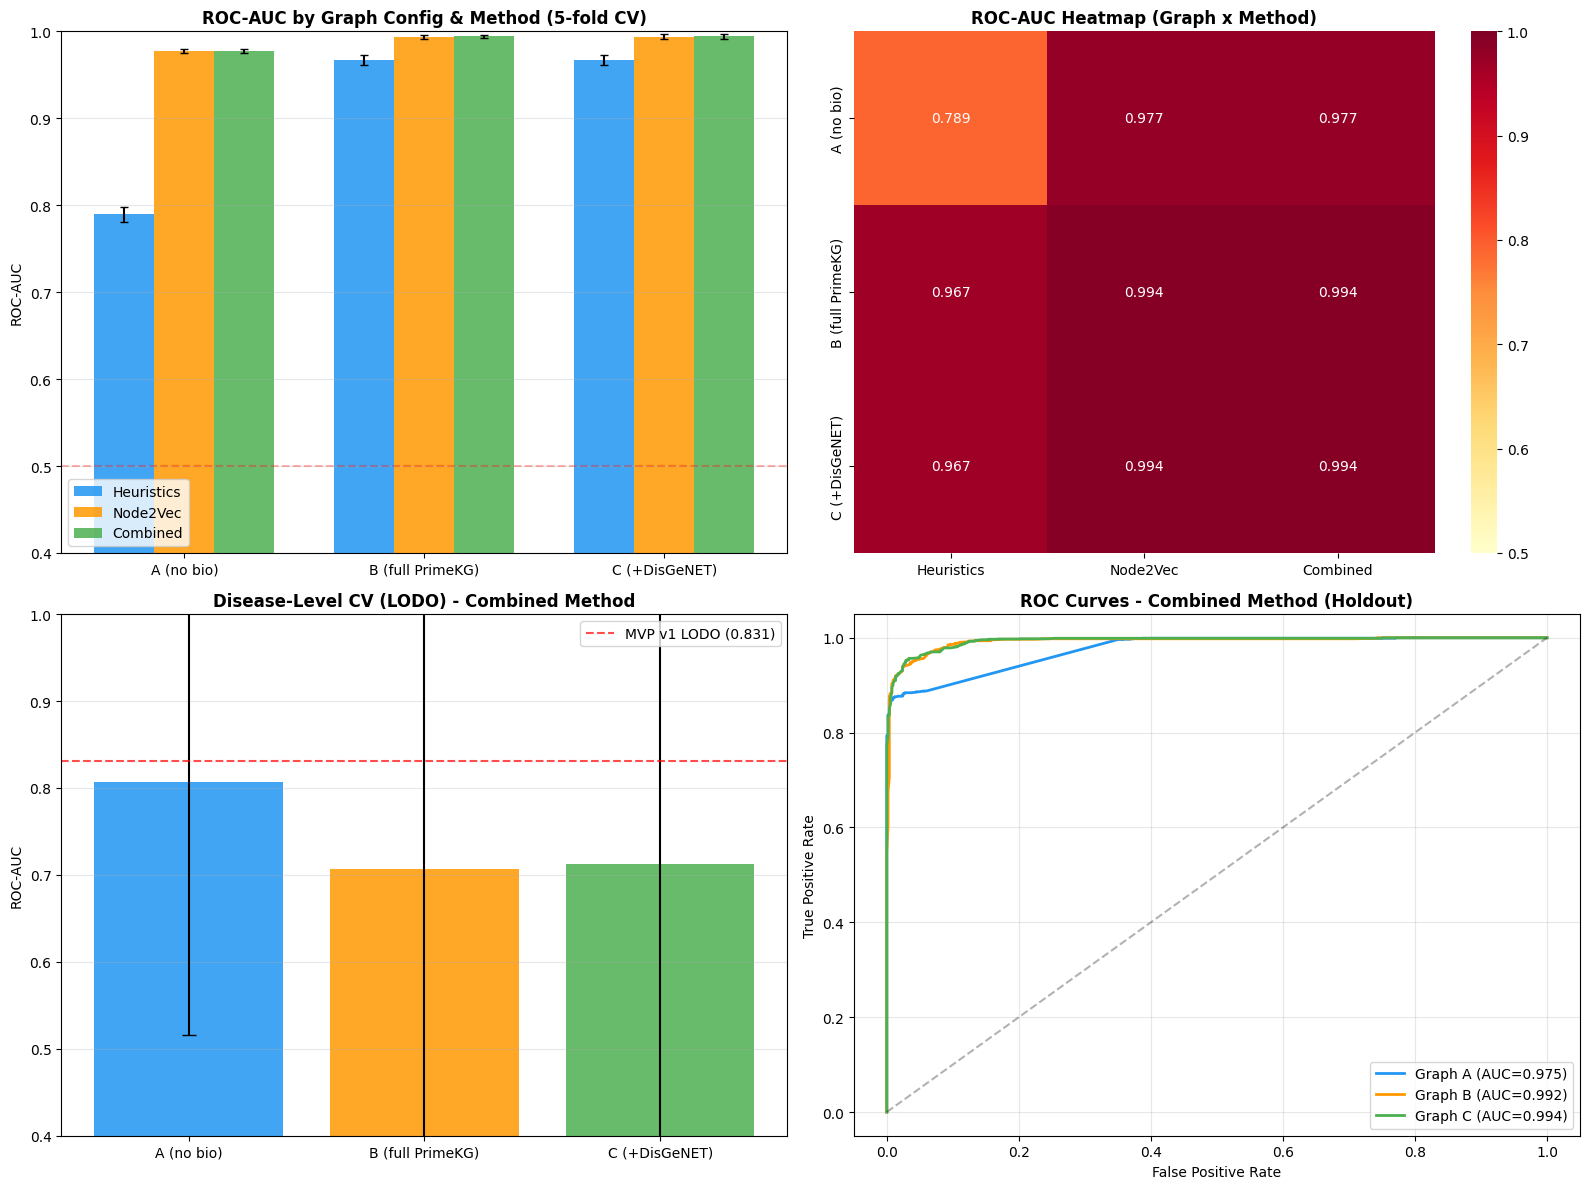

Saved: mvp_v2_results.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1. Bar chart: Methods across graph configs ---
ax = axes[0, 0]
graph_labels = ['A (no bio)', 'B (full PrimeKG)', 'C (+DisGeNET)']
method_labels = ['Heuristics', 'Node2Vec', 'Combined']
colors = ['#2196F3', '#FF9800', '#4CAF50']

x = np.arange(len(graph_labels))
width = 0.25

for i, method in enumerate(method_labels):
    vals = []
    errs = []
    for gname in ['A', 'B', 'C']:
        key = f'Graph {gname} - {method}'
        if key in results_df.index:
            vals.append(results_df.loc[key, 'roc_auc_mean'])
            errs.append(results_df.loc[key, 'roc_auc_std'])
        else:
            vals.append(0)
            errs.append(0)
    ax.bar(x + i * width, vals, width, yerr=errs, label=method, color=colors[i], capsize=3, alpha=0.85)

ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC by Graph Config & Method (5-fold CV)', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(graph_labels)
ax.legend()
ax.set_ylim([0.4, 1.0])
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
ax.grid(axis='y', alpha=0.3)

# --- 2. Heatmap: Graph x Method performance ---
ax = axes[0, 1]
heatmap_data = np.zeros((3, 3))
for i, gname in enumerate(['A', 'B', 'C']):
    for j, method in enumerate(['Heuristics', 'Node2Vec', 'Combined']):
        key = f'Graph {gname} - {method}'
        if key in results_df.index:
            heatmap_data[i, j] = results_df.loc[key, 'roc_auc_mean']

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=method_labels, yticklabels=graph_labels, ax=ax,
            vmin=0.5, vmax=1.0)
ax.set_title('ROC-AUC Heatmap (Graph x Method)', fontweight='bold')

# --- 3. LODO comparison ---
ax = axes[1, 0]
lodo_means = [lodo_results[g]['roc_auc'].mean() if g in lodo_results else 0 for g in ['A', 'B', 'C']]
lodo_stds = [lodo_results[g]['roc_auc'].std() if g in lodo_results else 0 for g in ['A', 'B', 'C']]

bars = ax.bar(graph_labels, lodo_means, yerr=lodo_stds, color=['#2196F3', '#FF9800', '#4CAF50'],
              capsize=5, alpha=0.85)
ax.axhline(y=0.831, color='red', linestyle='--', alpha=0.7, label='MVP v1 LODO (0.831)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Disease-Level CV (LODO) - Combined Method', fontweight='bold')
ax.legend()
ax.set_ylim([0.4, 1.0])
ax.grid(axis='y', alpha=0.3)

# --- 4. ROC curves for best models ---
ax = axes[1, 1]
from sklearn.model_selection import train_test_split

for gname, h_df, e_df, color in [
    ('A', heuristics_A, emb_features_A, '#2196F3'),
    ('B', heuristics_B, emb_features_B, '#FF9800'),
    ('C', heuristics_C, emb_features_C, '#4CAF50')
]:
    X_comb = np.hstack([h_df.values, e_df.values])
    X_tr, X_te, y_tr, y_te = train_test_split(X_comb, y, test_size=0.2, random_state=42, stratify=y)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_prob = rf.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'Graph {gname} (AUC={roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Combined Method (Holdout)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mvp_v2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mvp_v2_results.png")

## 11. Summary & Analysis

In [18]:
print("=" * 70)
print("MVP v2 SUMMARY: LINK PREDICTION FOR DRUG-DISEASE PREDICTION")
print("=" * 70)

print(f"\nDATASET: {len(df_dataset)} samples ({N_DISEASES} diseases, {N_DRUGS} drugs)")
print(f"  Contraindications: {(y == 1).sum()}, Indications: {(y == 0).sum()}")

print(f"\nGRAPH CONFIGURATIONS:")
for name, G in graphs.items():
    print(f"  {name}: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"  DisGeNET edges added to Graph C: {disgenet_edges_added:,}")

print(f"\n5-FOLD STRATIFIED CV RESULTS:")
print(f"{'Model':<40} {'ROC-AUC':>12}")
print("-" * 55)
for idx, row in results_df.iterrows():
    print(f"{idx:<40} {row['roc_auc_mean']:.3f}+/-{row['roc_auc_std']:.3f}")

print(f"\nDISEASE-LEVEL CV (LODO) - Combined Method:")
for gname in ['A', 'B', 'C']:
    if gname in lodo_results and len(lodo_results[gname]) > 0:
        lr = lodo_results[gname]
        print(f"  Graph {gname}: ROC-AUC={lr['roc_auc'].mean():.3f}+/-{lr['roc_auc'].std():.3f} "
              f"({len(lr)} diseases evaluated)")

print(f"\nCOMPARISON WITH MVP v1:")
print(f"  MVP v1 best (feature engineering): ROC-AUC=0.985, LODO=0.831")
print(f"  MVP v2 best (link prediction):     ROC-AUC={results_df.iloc[0]['roc_auc_mean']:.3f}")

print(f"\nKEY TAKEAWAYS:")

# Which graph config is best?
best_by_graph = {}
for gname in ['A', 'B', 'C']:
    graph_rows = results_df[results_df.index.str.contains(f'Graph {gname}')]
    if len(graph_rows) > 0:
        best_by_graph[gname] = graph_rows['roc_auc_mean'].max()

best_graph = max(best_by_graph, key=best_by_graph.get)
print(f"  1. Best graph config: Graph {best_graph} (ROC-AUC={best_by_graph[best_graph]:.3f})")

# Does DisGeNET help?
if 'B' in best_by_graph and 'C' in best_by_graph:
    dgn_diff = best_by_graph['C'] - best_by_graph['B']
    if dgn_diff > 0.005:
        print(f"  2. DisGeNET edges HELP: +{dgn_diff:.3f} ROC-AUC")
    elif dgn_diff < -0.005:
        print(f"  2. DisGeNET edges HURT: {dgn_diff:.3f} ROC-AUC")
    else:
        print(f"  2. DisGeNET edges have MINIMAL effect: {dgn_diff:+.3f} ROC-AUC")

# Link prediction vs feature engineering
best_v2_auc = results_df.iloc[0]['roc_auc_mean']
v1_v2_diff = best_v2_auc - 0.985
if v1_v2_diff > 0.005:
    print(f"  3. Link prediction OUTPERFORMS feature engineering: {v1_v2_diff:+.3f}")
elif v1_v2_diff > -0.005:
    print(f"  3. Link prediction is COMPARABLE to feature engineering: {v1_v2_diff:+.3f}")
else:
    print(f"  3. Feature engineering outperforms link prediction: {v1_v2_diff:+.3f}")

# Which method works best?
method_best = {}
for method in ['Heuristics', 'Node2Vec', 'Combined']:
    method_rows = results_df[results_df.index.str.contains(method)]
    if len(method_rows) > 0:
        method_best[method] = method_rows['roc_auc_mean'].max()
best_method = max(method_best, key=method_best.get)
print(f"  4. Best link prediction method: {best_method} (ROC-AUC={method_best[best_method]:.3f})")

print(f"\nNEXT STEPS:")
print(f"  - GNN-based link prediction (GCN, GAT, GraphSAGE)")
print(f"  - Temporal validation (train on older data, test on newer)")
print(f"  - Additional external data sources (DrugBank, CTD)")
print("\n" + "=" * 70)

MVP v2 SUMMARY: LINK PREDICTION FOR DRUG-DISEASE PREDICTION

DATASET: 14824 samples (328 diseases, 1000 drugs)
  Contraindications: 9574, Indications: 5250

GRAPH CONFIGURATIONS:
  A (no bio edges): 3,916 nodes, 34,999 edges


  B (full PrimeKG): 31,508 nodes, 915,564 edges
  C (PrimeKG+DisGeNET): 31,508 nodes, 915,564 edges
  DisGeNET edges added to Graph C: 0

5-FOLD STRATIFIED CV RESULTS:
Model                                         ROC-AUC
-------------------------------------------------------
Graph B - Combined                       0.994+/-0.002
Graph C - Combined                       0.994+/-0.002
Graph C - Node2Vec                       0.994+/-0.003
Graph B - Node2Vec                       0.994+/-0.002
Graph A - Combined                       0.977+/-0.002
Graph A - Node2Vec                       0.977+/-0.002
Graph B - Heuristics                     0.967+/-0.006
Graph C - Heuristics                     0.967+/-0.006
Graph A - Heuristics                     0.789+/-0.009

DISEASE-LEVEL CV (LODO) - Combined Method:
  Graph A: ROC-AUC=0.806+/-0.290 (44 diseases evaluated)
  Graph B: ROC-AUC=0.707+/-0.341 (44 diseases evaluated)
  Graph C: ROC-AUC=0.713+/-0.343 (44 diseases evaluated)

COMPARISON 